In [26]:
# Warehouse Capacity Analysis

In [ ]:
# Question 1: How many locations does each store have?

In [ ]:
## Analysis

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [3]:
load_dotenv()

True

In [4]:
connection_string = (
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

engine = create_engine(connection_string)

In [5]:
print("Connected successfully!")

Connected successfully!


In [6]:
query = """
SELECT 
	a2.long_name as store,
	a1.long_name,
    l.packing_type,
    l.location_category,
    l.location_status
FROM 
    Locations l
LEFT JOIN
    Areas a1
ON
    l.address = a1.address
LEFT JOIN
    Areas a2
ON
    a1.zone_address = a2.address
"""

df_locations = pd.read_sql(query, engine)

In [7]:
df_locations.head(10)

,store,long_name,packing_type,location_category,location_status
0,DPL,DPL010101,C1,D1,O
1,DPL,DPL010102,C2,D1,O
2,DPL,DPL010103,C1,D2,O
3,DPL,DPL010104,C3,D2,O
4,DPL,DPL010105,C3,D3,F
5,DPL,DPL010201,C1,D1,O
6,DPL,DPL010202,C2,D1,O
7,DPL,DPL010203,C1,D2,O
8,DPL,DPL010204,C3,D2,O
9,DPL,DPL010205,C3,D3,O


In [8]:
locations_per_store = df_locations.groupby("store").size()

In [9]:
locations_per_store

store
ASM     630
BUF     126
DCN     750
DCR     900
DCS     990
DPL    1500
KLT     280
LOG    1000
MTR     735
PKG     600
PRT     450
RPK     400
SBC     630
SP1     600
SP2     280
SP3     630
SUP     320
VNX     150
WHE     480
WHN     440
WHS     960
dtype: int64

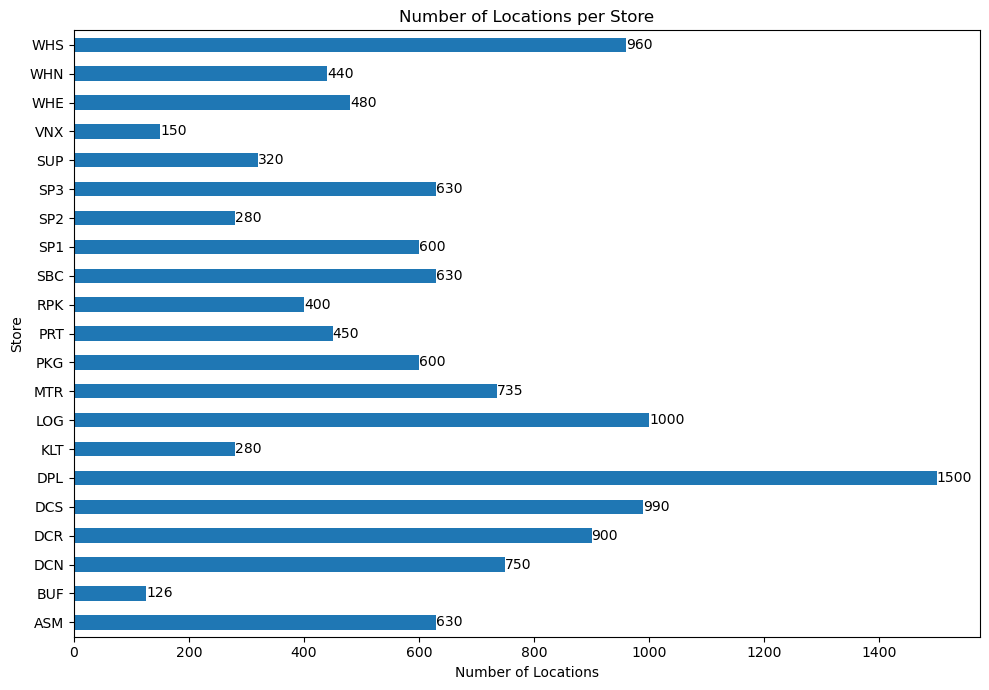

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

locations_per_store.plot(
    kind="barh",
    ax=ax
)

ax.bar_label(ax.containers[0])

ax.set_title("Number of Locations per Store")
ax.set_xlabel("Number of Locations")
ax.set_ylabel("Store")

plt.tight_layout()
plt.show()

In [11]:
## Finding
# Most locations can be found in store DPL, while BUF has the fewest. See the chart above for the other stores.

In [16]:
# Question 2: How many storages does each building have?

In [17]:
## Analysis

In [18]:
query = """
SELECT 
	b.long_name as building_name,
    a.long_name as store_name
FROM 
    Areas a
LEFT JOIN
	Building b
ON
	a.building_address = b.address
WHERE
	a.zone_address IS NULL;
"""

df_stores = pd.read_sql(query, engine)

In [19]:
stores_per_building = df_stores.groupby("building_name").size()

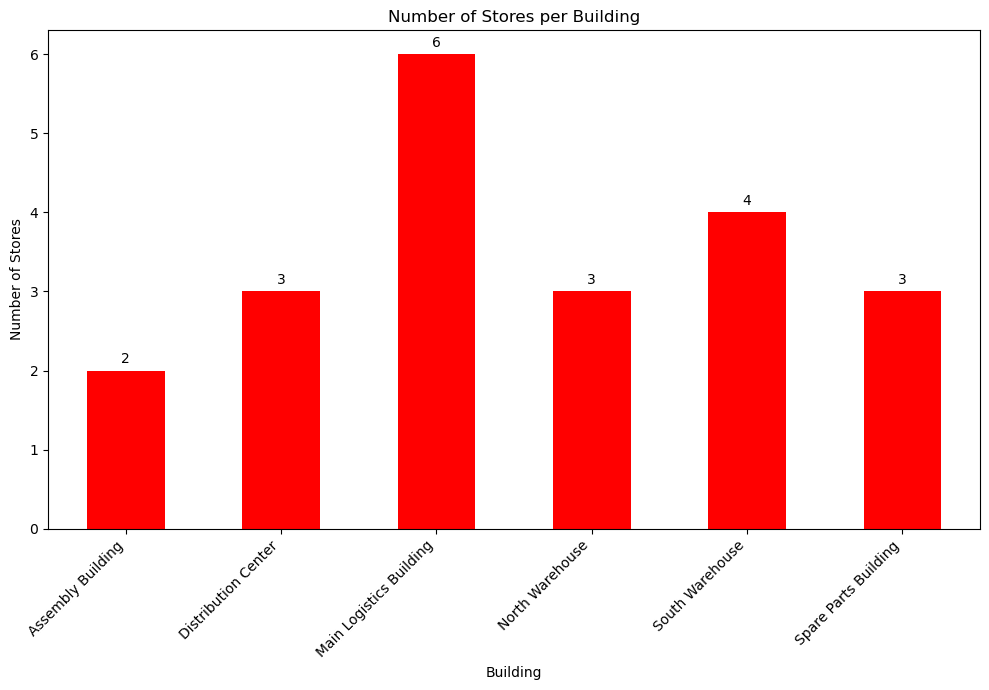

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

stores_per_building.plot(
    kind="bar",
    ax=ax,
    color="red"
)

ax.bar_label(ax.containers[0], padding=3)

ax.set_title("Number of Stores per Building")
ax.set_xlabel("Building")
ax.set_ylabel("Number of Stores")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [38]:
## Finding
# Most stores can be found in Main Logistics Building, Assembly Building has the fewest. See the chart above for the other stores.

In [21]:
# Question 3: How many different packing types are there in each building?

In [22]:
## Analysis

In [23]:
query = """
SELECT 
	b.long_name as building_name,
    l.packing_type
FROM
	Locations l
LEFT JOIN
	Areas a1
ON
	l.address = a1.address
LEFT JOIN
	Building b
ON
	a1.building_address = b.address;
"""

df_packing_type_per_building = pd.read_sql(query, engine)

In [24]:
packing_type_per_building = df_packing_type_per_building.groupby(["building_name", "packing_type"]).size()

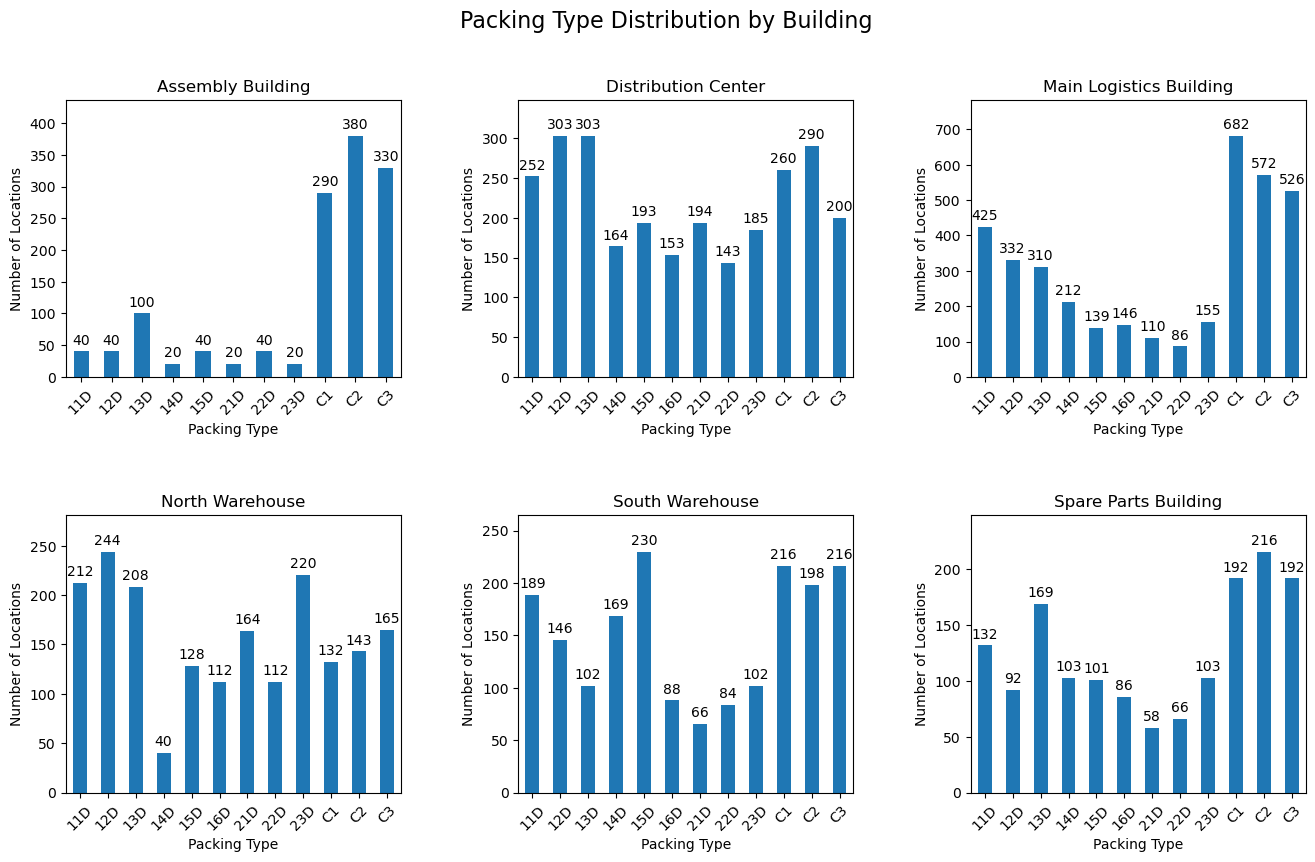

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes = axes.flatten()

for ax, (building, data) in zip(
    axes,
    packing_type_per_building.groupby(level=0)
):
    data = data.droplevel(0)

    data.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(building)
    ax.set_xlabel("Packing Type")
    ax.set_ylabel("Number of Locations")

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.bar_label(
        ax.containers[0],
        padding=3
    )

    # Add space above the highest bar
    ax.margins(y=0.15)


plt.suptitle(
    "Packing Type Distribution by Building",
    fontsize=16
)

# Space between individual charts
plt.subplots_adjust(
    wspace=0.35,
    hspace=0.5
)

plt.show()

In [57]:
## Finding
# There is a significant difference between the Assembly Building and the other buildings 
# when it comes to the distribution of box and pallet packaging.

In [58]:
# Question 4: What is the overall filling rate for each store, and how does it vary by packing type?

In [59]:
## Analysis

In [27]:
query = """
SELECT 
	a2.long_name as store,
	l.packing_type,
    l.location_status
FROM
	Locations l
LEFT JOIN
	Areas a1
ON
	l.address = a1.address
LEFT JOIN
	Areas a2
ON
	a1.zone_address = a2.address;
"""

df_location_statuses = pd.read_sql(query, engine)

In [28]:
store_occupancy = (
    df_location_statuses
    .groupby("store")
    .agg(
        number_of_locations=("store", "size"),
        occupied_locations=("location_status", lambda x: (x == "O").sum())
    )
    .reset_index()
)

store_occupancy["filling_rate"] = (store_occupancy["occupied_locations"] / store_occupancy["number_of_locations"])*100

In [29]:
store_occupancy

,store,number_of_locations,occupied_locations,filling_rate
0,ASM,630,540,85.714286
1,BUF,126,112,88.888889
2,DCN,750,608,81.066667
3,DCR,900,755,83.888889
4,DCS,990,824,83.232323
5,DPL,1500,1293,86.200000
6,KLT,280,250,89.285714
7,LOG,1000,826,82.600000
8,MTR,735,621,84.489796
9,PKG,600,504,84.000000


In [30]:
import matplotlib.ticker as mtick

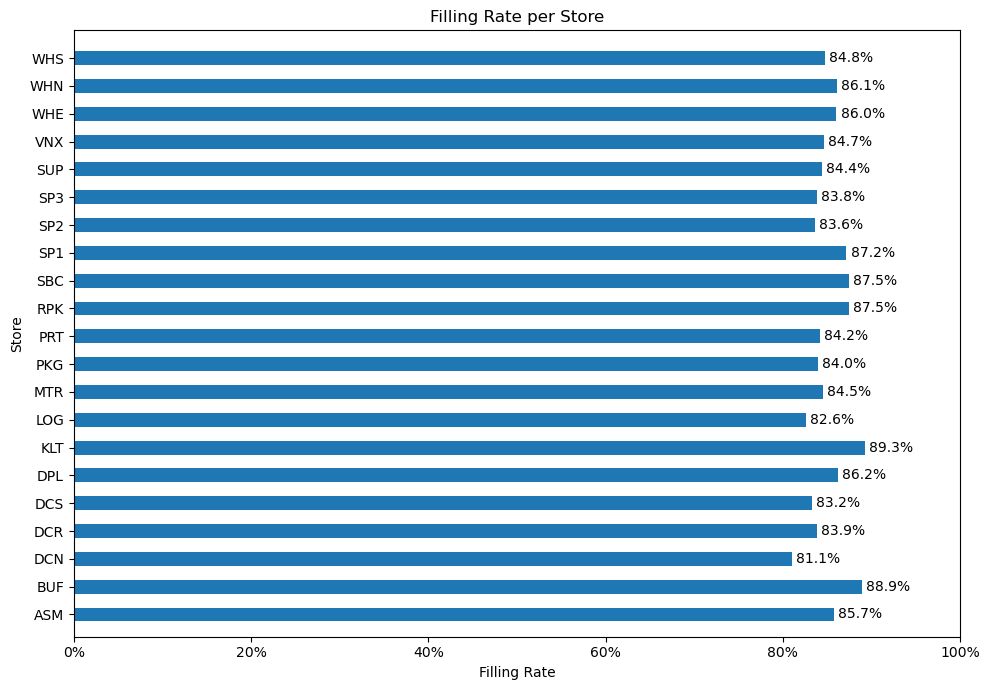

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))

store_occupancy.plot(
    kind="barh",
    x="store",
    y="filling_rate",
    ax=ax
)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

ax.set_title("Filling Rate per Store")
ax.set_xlabel("Filling Rate")
ax.set_ylabel("Store")

ax.get_legend().remove()

ax.set_xlim(0, 100)

# Add space above and below the bars
ax.set_ylim(-0.8, len(store_occupancy))

plt.tight_layout()
plt.show()

In [90]:
packing_occupancy = (
    df_location_statuses
    .groupby("packing_type")
    .agg(
        number_of_locations=("packing_type", "size"),
        occupied_locations=("location_status", lambda x: (x == "O").sum())
    )
    .reset_index()
)

packing_occupancy["filling_rate"] = (packing_occupancy["occupied_locations"] / packing_occupancy["number_of_locations"])*100

In [91]:
packing_occupancy

,packing_type,number_of_locations,occupied_locations,filling_rate
0,11D,1250,1065,85.200000
1,12D,1157,979,84.615385
2,13D,1192,993,83.305369
3,14D,708,615,86.864407
4,15D,831,707,85.078219
5,16D,585,491,83.931624
6,21D,612,527,86.111111
7,22D,531,448,84.369115
8,23D,785,657,83.694268
9,C1,1772,1505,84.932280


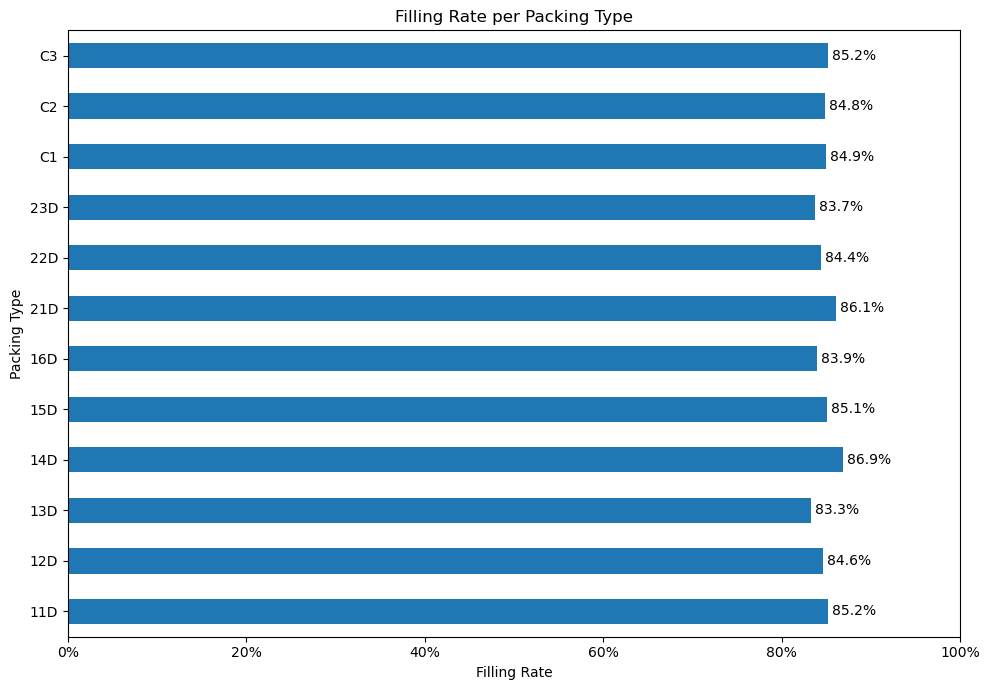

In [92]:
fig, ax = plt.subplots(figsize=(10, 7))

packing_occupancy.plot(
    kind="barh",
    x="packing_type",
    y="filling_rate",
    ax=ax
)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

ax.set_title("Filling Rate per Packing Type")
ax.set_xlabel("Filling Rate")
ax.set_ylabel("Packing Type")

ax.get_legend().remove()

ax.set_xlim(0, 100)

# Add space above and below the bars
# ax.set_ylim(-0.8, len(store_occupancy))

plt.tight_layout()
plt.show()

In [93]:
## Finding
# The conclusion is that the filling rate varies much more between stores than between packing types. 
# Nevertheless, the filling rate remains around 85%, as specified in the Python code when randomizing the location_status column.